Drew Pickett
ML Class

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
data = load_diabetes(as_frame=True, scaled=False)
df = data.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

DataFrame Summary Statistics:
              age         sex         bmi          bp          s1          s2  \
count  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000   
mean    48.518100    1.468326   26.375792   94.647014  189.140271  115.439140   
std     13.109028    0.499561    4.418122   13.831283   34.608052   3

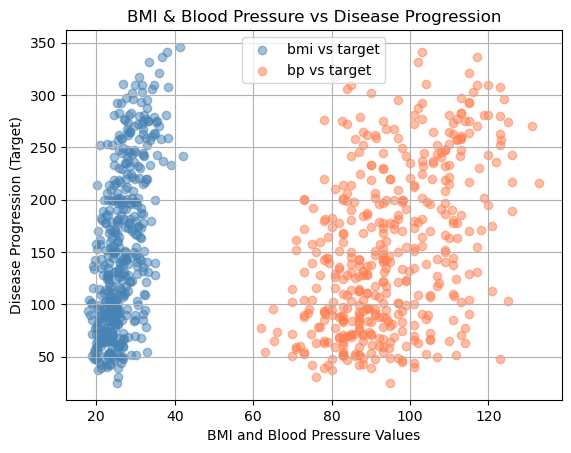

In [3]:
print("\nDataFrame Information:")
print(df.info())
print("\nDataFrame Summary Statistics:")
print(df.describe())

# Features (X) and Target Variable (y)
X = df[['bmi', 'bp']]
y = df['target']

# Scatter plots of features vs target
plt.scatter(df['bmi'], df['target'], alpha=0.5, label='bmi vs target', color='steelblue')
plt.scatter(df['bp'], df['target'], alpha=0.5, label='bp vs target', color='coral')
plt.xlabel("BMI and Blood Pressure Values")
plt.ylabel("Disease Progression (Target)")
plt.legend()
plt.title("BMI & Blood Pressure vs Disease Progression")
plt.grid(True)
plt.show()

In [4]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")


Mean Squared Error: 3740.5070
R-squared Score: 0.2940


I picked bmi and bp because they were the two features I was most familiar with. My model performed decently well for making predictions with only two features, the square rooted mse value is 61 so my predictions were 61 units off on average. This is ok becuase the target variable had a range of rougly 25 to 350. The r-squared value shows us that the model explained 29% of the varaition in disease progression, this is decent using only 2 features.